In [51]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
from scipy import  stats
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm

1. Research question
2. Markov-chain simulation
3. Transition-matrix estimation
4. Stationary distribution
5. Regime durations
6. Convergence experiment
7. Markov-switching return generatorx
8. Synthetic diagnostics
9. SPY–synthetic comparison
10. Sensitivity experiment
11. Conclusion

# Can a Two-State Markov-Switching Mechanism Reproduce SPY's Stylised Facts?

## Abstract
[3 cümle. En son yaz.]

## 1. Purpose
[Rapor 1'in bıraktığı yerden başla: kalın kuyruk + volatilite kümelenmesi
gözlendi, iki rejimli karışım önerildi ama gösterilmedi. Bu rapor o öneriyi
sınıyor. Bir paragraf.]

## 2. Model
### 2.1 The chain
[P matrisi, durum tanımları, satır toplamı 1]
### 2.2 The observation equation
[r_t = μ + σ_{S_t}·ε_t, ε ~ N(0,1). Ortak ortalama, rejime bağlı varyans —
ve neden bu spesifikasyon: Rapor 1'deki ACF bulgusu]
### 2.3 Implied moments
[Karışım varyansı ve kurtosis formülleri, kendi türettiğin haliyle.
Teorik değerler: std 0.026, excess kurtosis 6.75]

## 3. Chain verification
[Kod doğru mu — üç kontrol, tablo hâlinde kısa tut:]
- P̂ (sayımdan) vs P
- π: kapalı form / lineer sistem / simülasyon
- Beklenen süreler 1/(1−p_ii) vs gözlenen
[Not: final raporda bu bölüm eke taşınır, şimdilik burada dursun]

## 4. Calibration
[Parametreler nereden geldi. DÜRÜST OL: kayan volatilite grafiğinden göz
kararıyla seçildi, veriden tahmin EDİLMEDİ. Bu cümle 7. bölümün anahtarı.]

## 5. Results
### 5.1 Synthetic series diagnostics
[Figürler: rejim gölgeli getiri serisi, kayan volatilite, histogram +
Gaussian + karışım eğrisi, QQ, ACF üçlüsü]
### 5.2 Comparison with SPY
[Ana tablo: teorik | SPY | sentetik n=1042 | sentetik n=50.000]

## 6. Sensitivity
[Beş senaryo tablosu. Hangi parametre hangi özelliği kontrol ediyor —
σ farkı kurtosis'i, P hafızayı. Varsa aralarındaki gerilim.]

## 7. Discussion
[Ne üretildi, ne üretilemedi, neden. Üç sebep. Ve kritik ayrım: bu açık
parametre seçiminden mi model yapısından mı geliyor — bu raporla ayırt
edilemez, MLE gerekiyor.]

## 8. Limitations
[Parametreler tahmin edilmedi; tek simülasyon yolu (Monte Carlo tekrarı yok);
rejim içi normallik varsayımı test edilmedi; n=1042'de örneklem gürültüsü]

## 9. Next step
[MLE ile parametre tahmini — model yapısı ile parametre seçimini ancak o
zaman ayırabileceksin]

14. Sonuç paragrafında cevaplayacağın sorular

Kendi sonuçlarına göre şunları yaz:

Model raw-return ACF’sinin düşük olmasını üretti mi?
Absolute-return ACF’sinde pozitif kalıcılık üretti mi? +
Pozitif excess kurtosis üretti mi?
SPY’ın 9.48 kurtosis değerine ulaştı mı?
Sentetik volatilite hafızası SPY’dan daha kısa mı?
Hangi parametre hangi özelliği değiştirdi?
Model neden henüz gerçek SPY modeli olarak kabul edilemez?

ilk hafta volatilite kümelenmesi olduğu görüldü ve getirinin bir tane normal dağılımdan değil 2 tane  biri yüksek varyanslı biri küçük varyanslı olacak şekilde iç içe geçmiş dağılımdan gelmiş olabileceği varsayıldı

Gösterebilir:
İki durumlu mekanizma bu istatistikleri üretebiliyor.

Başta bir bir transation matris bulucam ondan sonrasında ona 1 0 dizisi ürettirip sentetikle test ediyoruz

### 2. MODEL

### 2.1 The Chain
P matrix is a Markov matrix, where each state represents the volatility regime switching probabilities. The probability of transitioning from state $i$ to state $j$ is denoted by $p_{ij}$. Each row sums to 1 because the system must transition to one of the possible states. In this model, the probability of switching from low volatility to high volatility is 0.05, and from high volatility to low volatility is 0.20.T hese probabilities were chosen arbitrarily for illustrative purposes, rather than for accurate empirical modeling.


### 2.2 The Observation Equation
The latent volatility state is linked to the observed weekly log return through

$$
r_t = \mu + \sigma_{S_t}\varepsilon_t,
\qquad
\varepsilon_t \overset{\mathrm{iid}}{\sim} \mathcal{N}(0,1).
$$

Here, $S_t \in \{0,1\}$ denotes the unobserved volatility regime, $\mu$ is the common weekly mean return, and $\sigma_{S_t}$ is the regime-dependent standard deviation. Conditional on the current regime,

$$
r_t \mid S_t = 0 \sim \mathcal{N}(\mu,\sigma_0^2),
$$

and

$$
r_t \mid S_t = 1 \sim \mathcal{N}(\mu,\sigma_1^2).
$$

In the simulation, $\sigma_0 = 0.013$ represents the low-volatility regime, while $\sigma_1 = 0.052$ represents the high-volatility regime.

A common mean is imposed because the initial SPY analysis showed little autocorrelation in raw returns but persistent autocorrelation in absolute and squared returns. The model therefore places regime dependence in the conditional variance rather than in the conditional mean. Although the Gaussian shocks are serially independent, persistence in $S_t$ produces clusters of large and small return magnitudes over time.


### 2.3 Implied Moments

Under the stationary distribution $\boldsymbol{\pi}=(0.8,0.2)$, a randomly selected week belongs to the low-volatility regime with probability $\pi_0=0.8$ and to the high-volatility regime with probability $\pi_1=0.2$.

Because both regimes have the same conditional mean, the unconditional expected return is

$$
\begin{aligned}
\mathbb{E}[r_t]
&=
\sum_{i=0}^{1}
\pi_i\mathbb{E}[r_t\mid S_t=i] \\
&=
\pi_0\mu+\pi_1\mu \\
&=
\mu.
\end{aligned}
$$

Using the law of total variance,

$$
\operatorname{Var}(r_t)
=
\mathbb{E}\left[\operatorname{Var}(r_t\mid S_t)\right]
+
\operatorname{Var}\left(\mathbb{E}[r_t\mid S_t]\right).
$$

The second term is zero because the conditional mean is $\mu$ in both regimes. Therefore,

$$
\operatorname{Var}(r_t)
=
\pi_0\sigma_0^2+\pi_1\sigma_1^2.
$$

Using $\pi_0=0.8$, $\pi_1=0.2$, $\sigma_0=0.013$, and $\sigma_1=0.052$ gives

$$
\begin{aligned}
\operatorname{Var}(r_t)
&=
0.8(0.013)^2+0.2(0.052)^2 \\
&=
0.000676.
\end{aligned}
$$

Hence, the implied weekly standard deviation is

$$
\operatorname{Std}(r_t)
=
\sqrt{0.000676}
=
0.026.
$$

Although returns are conditionally Gaussian within each regime, their unconditional distribution is a Gaussian mixture. For a Gaussian variable, the fourth central moment is

$$
\mathbb{E}\left[(r_t-\mu)^4\mid S_t=i\right]
=
3\sigma_i^4.
$$

Therefore, the unconditional fourth central moment is

$$
\mathbb{E}\left[(r_t-\mu)^4\right]
=
3\left(\pi_0\sigma_0^4+\pi_1\sigma_1^4\right).
$$

The implied kurtosis is consequently

$$
\operatorname{Kurt}(r_t)
=
\frac{
3\left(\pi_0\sigma_0^4+\pi_1\sigma_1^4\right)
}{
\left(\pi_0\sigma_0^2+\pi_1\sigma_1^2\right)^2
}.
$$

Substituting the model parameters gives

$$
\operatorname{Kurt}(r_t)
=
\frac{
3\left[0.8(0.013)^4+0.2(0.052)^4\right]
}{
(0.000676)^2
}
=
9.75.
$$

Since a Gaussian distribution has kurtosis equal to $3$, the implied excess kurtosis is

$$
\operatorname{Excess\ Kurtosis}(r_t)
=
9.75-3
=
6.75.
$$

Thus, the model produces an overall weekly standard deviation of $0.026$ and positive excess kurtosis even though returns are Gaussian conditional on each regime. However, the theoretical excess kurtosis of $6.75$ remains below the empirical SPY value of approximately $9.48$, indicating that the baseline model does not fully reproduce the observed tail heaviness.



## 3. Chain Vertification
The Markov chain was simulated using the transition probabilities defined in matrix $P$. The simulation generates a sequence of states, denoted as 1 and 0, representing the volatility regimes. Empirical transition probabilities were then calculated from this generated array. As expected, there is no significant difference between the empirical results and theoretical probabilities. Both the theoretical and empirical stationary distributions were calculated and compared to verify the simulation.

| Metric | Theoretical (Model) | Empirical (Simulation) | Verification |
| :--- | :--- | :--- | :--- |
| **Transition Matrix** | $P$ | $\hat{P}$ (calculated from state counts) | Consistent |
| **Stationary Distribution** | $\pi$ (closed-form / linear system) | $\hat{\pi}$ (from simulation frequencies) | Consistent |
| **Expected Sojourn Time** | $\mathbb{E}[T_i] = \frac{1}{1-p_{ii}}$ | Observed mean duration in state $i$ | Consistent |
: Chain Verification Methods and Results {#tbl-verification}


In [52]:
P_matrice = np.array([[0.95, 0.05],
              [0.20, 0.80]])
#0 : low volatility
#1 : high volatility

rng = np.random.default_rng(seed = 94)

def simulate_chain(P,n,s0,rng):
    states = np.zeros(n, dtype = int)
    states[0] = s0
    number_of_states = P.shape[0] # satir sayisi
    for i in range(1,n):
        current_state = states[i-1]
        transition_probs = P[current_state]
        states[i] = rng.choice(number_of_states, p = transition_probs)

    return states

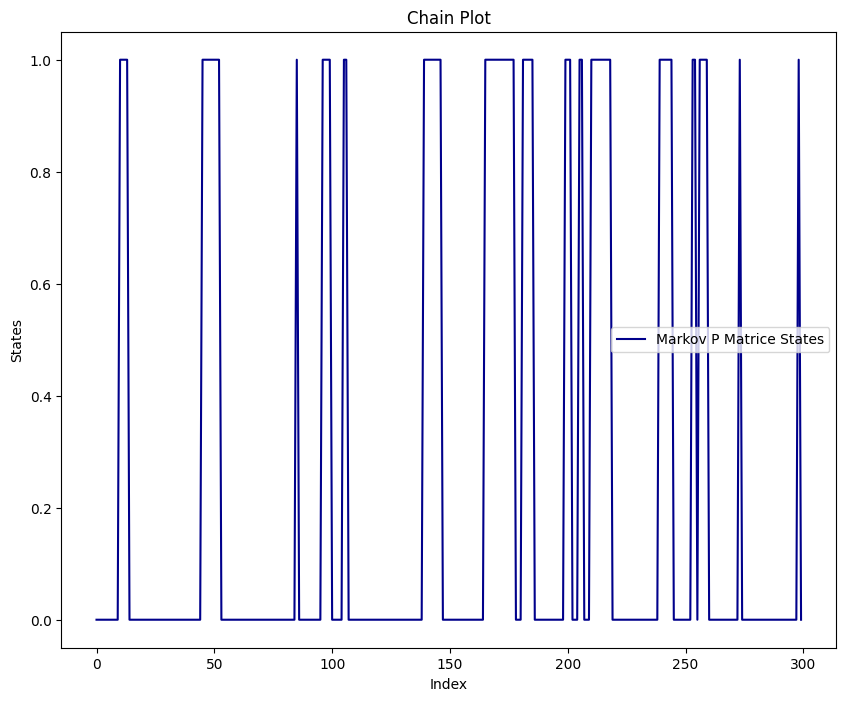

{0: 796, 1: 247}


In [53]:
spy_weekly_data = pd.read_csv("../data/customized_spy_data_2000-2019.csv")
spy_data_size = len(spy_weekly_data["Log_Return"].dropna())

state_chain_1042 = simulate_chain(P_matrice, spy_data_size, 0, rng)

plt.figure(figsize=(10,8))
plt.plot(range(300), state_chain_1042[:300], label = "Markov P Matrice States", color = "darkblue")
plt.title("Chain Plot")
plt.xlabel("Index")
plt.ylabel("States")
plt.legend()
plt.show()
states, counts = np.unique(state_chain_1042, return_counts=True)
count_result = dict(zip(states.tolist(), counts.tolist()))
print(count_result)

In [54]:
today = state_chain_1042[:-1]
tomorrow = state_chain_1042[1:]
N00 = np.sum((today == 0 ) & (tomorrow==0 ))
N01 = np.sum((today == 0 ) & (tomorrow == 1))
N10 = np.sum((today == 1) & (tomorrow == 0))
N11 = np.sum((today == 1 ) & (tomorrow == 1))

N_matrice = np.array([[N00,N01],
                      [N10,N11]])
print(f"Calculated Matrice:\n {N_matrice}")

sum_of_rows = N_matrice.sum(axis=1,keepdims=True)
P_hat = N_matrice / sum_of_rows

print("\nReal P:\n", P_matrice)
print("\nEstimated P-hat:\n", P_hat)
print("\nDifferance (P-hat - P):\n", P_hat - P_matrice)

Calculated Matrice:
 [[755  41]
 [ 40 206]]

Real P:
 [[0.95 0.05]
 [0.2  0.8 ]]

Estimated P-hat:
 [[0.94849246 0.05150754]
 [0.16260163 0.83739837]]

Differance (P-hat - P):
 [[-0.00150754  0.00150754]
 [-0.03739837  0.03739837]]


In [55]:
#Stationary Distributionu bulma

# sQ = s

n = P_matrice.shape[0]

A = P_matrice.T - np.eye(n)

b = np.zeros(n)

A[-1, :] = 1  #normalize ediliyor
b[-1] = 1

s = np.linalg.solve(A,b)

print("Stationary distribution:", s)
print("sQ:", s @ P_matrice)
print("sQ = s :", np.allclose(s @ P_matrice, s))


n_1042 = len(state_chain_1042)
print("\n--- PI (STATIONARY) COMPARISON ---")
print(f"Empirical Pi (State 0): {count_result[0]/n_1042:.4f} | Theoretical s[0]: {s[0]:.4f}")
print(f"Empirical Pi (State 1): {count_result[1]/n_1042:.4f} | Theoretical s[1]: {s[1]:.4f}")

Stationary distribution: [0.8 0.2]
sQ: [0.8 0.2]
sQ = s : True

--- PI (STATIONARY) COMPARISON ---
Empirical Pi (State 0): 0.7632 | Theoretical s[0]: 0.8000
Empirical Pi (State 1): 0.2368 | Theoretical s[1]: 0.2000


In [56]:
#Ortalama Rejim kalım süresi geometrik hesaplanır çünkü mantıken düşündüğümüzde rejimin bir duruma gelmesi geometrik dağılır 0. rejimdeysek 1 e geçme olasılıgımız kaç denenin sonunda geçtiğimiz geometrik dağılımın sorusudur.
#X ~ Geom(p) ise E(X) = 1/1-pii dir proof omitted. pii - > rejimde kalma , 1-pii rejimdden cıkma 
#Markov swithchinge göre  memoryless bir yapı var olasılık gerçekten sahip mi yoksa rejimde durdurkça değişiyor mu 

# Model-implied durations using the true transition matrix
theoretical_low_duration = 1 / (1 - P_matrice[0, 0])
theoretical_high_duration = 1 / (1 - P_matrice[1, 1])

# Empirical durations using transition counts
empirical_low_duration = (N00 + N01) / N01
empirical_high_duration = (N10 + N11) / N10

# Durations implied by the estimated transition matrix
estimated_low_duration = 1 / (1 - P_hat[0, 0])
estimated_high_duration = 1 / (1 - P_hat[1, 1])

print("\n--- REGIME DURATIONS ---")

print(f"Theoretical low-vol duration : {theoretical_low_duration:.4f}")
print(f"Empirical low-vol duration   : {empirical_low_duration:.4f}")
print(f"P-hat low-vol duration       : {estimated_low_duration:.4f}")

print("-" * 45)

print(f"Theoretical high-vol duration: {theoretical_high_duration:.4f}")
print(f"Empirical high-vol duration  : {empirical_high_duration:.4f}")
print(f"P-hat high-vol duration      : {estimated_high_duration:.4f}")


--- REGIME DURATIONS ---
Theoretical low-vol duration : 20.0000
Empirical low-vol duration   : 19.4146
P-hat low-vol duration       : 19.4146
---------------------------------------------
Theoretical high-vol duration: 5.0000
Empirical high-vol duration  : 6.1500
P-hat high-vol duration      : 6.1500


## 4. Calibration

Crucially, the parameters governing the Markov-switching model—both the transition probabilities and the state-dependent volatilities—were not strictly estimated from the empirical SPY data using formal statistical techniques such as Maximum Likelihood Estimation (MLE). Instead, they were heuristically calibrated based on a visual inspection of the SPY rolling volatility graph presented in the initial analysis. 

The conditional standard deviations, $\sigma_0 = 0.013$ and $\sigma_1 = 0.052$, were selected by eye to approximate the baseline tranquility of the market and the extreme spikes observed during crisis periods, respectively. Similarly, the transition probabilities $p_{00} = 0.95$ and $p_{11} = 0.80$ were chosen manually to reflect a well-known market stylized fact: low-volatility bull markets are highly persistent, whereas high-volatility distress periods are severe but relatively short-lived. 

Because these parameters are purely illustrative rather than empirically optimized, any discrepancies between the synthetic series and the actual SPY data must be interpreted with caution. This distinction between *model structure* and *parameter selection* forms the core of the discussion in Section 7.

In [57]:
#Şimdi bu rejimlerden markov switching modelini kullanarak 2 rejimli sistemden haftalık return elde edicem. 1040 hafta üzerinden bir return oluşturmak istiyorum markov switching model oalrak da rt = mu +std(st)Z(0,1) kullanıcam

logReturn_mean = spy_weekly_data["Log_Return"].mean()
low_vol_average_std = 0.013
high_vol_average_std = 0.052

def markov_switching_return(mu, low_vol, high_vol, regime, rng_obj):
    local_noise = rng_obj.normal(loc=0.0, scale=1.0, size=len(regime))
    volatility_array = np.where(regime == 0, low_vol, high_vol)
    log_return_array = mu + (volatility_array * local_noise)
    return log_return_array


log_return_array = markov_switching_return(logReturn_mean, low_vol_average_std, high_vol_average_std, state_chain_1042, rng)

print(log_return_array)

[-0.00070386 -0.0209455  -0.00976074 ...  0.00720608 -0.06224522
  0.04484166]


In [58]:
synth_return = pd.DataFrame(log_return_array, columns = ["Log_Return"])
weekly_index = pd.date_range(start = "2000-01-07", freq = "W-FRI", periods = len(synth_return))
synth_return.index = weekly_index
print(synth_return.head())

            Log_Return
2000-01-07     -0.0007
2000-01-14     -0.0209
2000-01-21     -0.0098
2000-01-28      0.0155
2000-02-04     -0.0166


In [59]:
synth_return["Rolling_Weekly_Volatility"] = synth_return["Log_Return"].rolling(window = 26).std()
synth_return["Rolling_Annual_Volatility"] = synth_return["Rolling_Weekly_Volatility"] * np.sqrt(52)
synth_return["Rolling_Weekly_Volatility"]
max_vol = synth_return["Rolling_Annual_Volatility"].max()
max_vol_date = synth_return["Rolling_Annual_Volatility"].idxmax()
min_vol = synth_return["Rolling_Annual_Volatility"].min()
min_vol_date = synth_return["Rolling_Annual_Volatility"].idxmin()
print(f"Minimum annual volatility: {min_vol:.1%} on {min_vol_date:%Y-%m-%d}")
print(f"Maximum annual volatility: {max_vol:.1%} on {max_vol_date:%Y-%m-%d}")

Minimum annual volatility: 7.0% on 2007-10-05
Maximum annual volatility: 35.1% on 2010-01-15


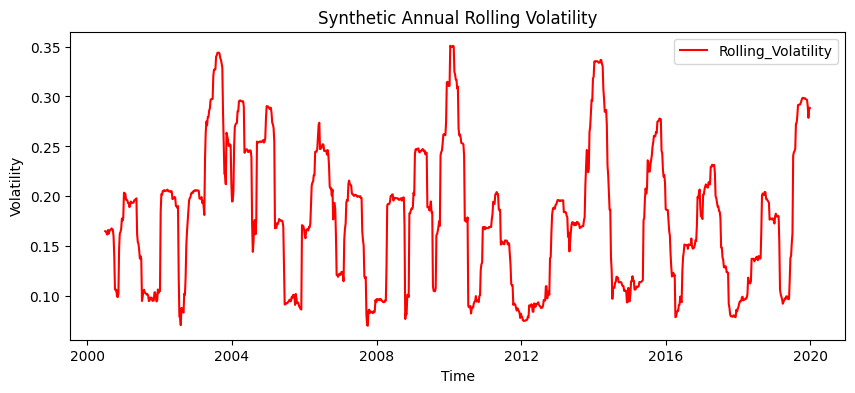

In [60]:
plt.figure(figsize=(10, 4)) 
plt.plot(synth_return.index, synth_return["Rolling_Annual_Volatility"], color="red", label="Rolling_Volatility")
plt.title("Synthetic Annual Rolling Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.show() 

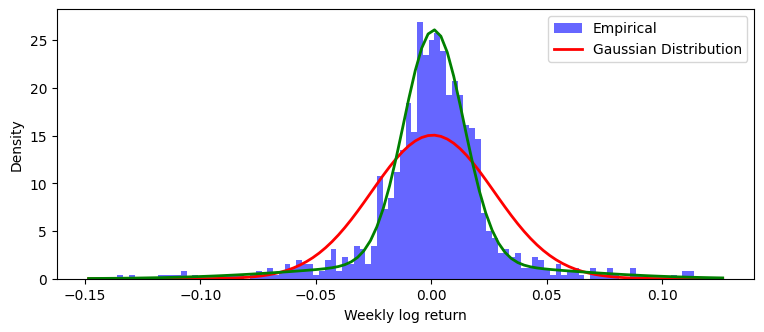

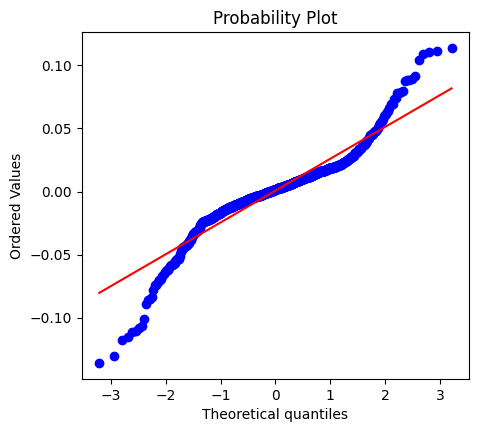

Excess Kurtosis Value: 5.03


In [61]:
log_returns_synth = synth_return["Log_Return"].dropna()

mu = log_returns_synth.mean()
std = log_returns_synth.std()

plt.figure(figsize=(9,3.5))
plt.hist(log_returns_synth, bins=100, density=True, alpha=0.6, color='blue', label='Empirical')

xmin, xmax = plt.xlim()

x = np.linspace(xmin, xmax, 100)

p = stats.norm.pdf(x, mu, std)

plt.plot(x, p, linewidth=2, color="red", label="Gaussian Distribution")
plt.xlabel("Weekly log return")
plt.ylabel("Density")
plt.legend()

mixture_pdf = (
    s[0] * stats.norm.pdf(x, loc=logReturn_mean, scale=low_vol_average_std)
    + s[1] * stats.norm.pdf(x, loc=logReturn_mean, scale=high_vol_average_std)
)
plt.plot(x, mixture_pdf, color="green", lw=2,
         label="Two-Gaussian mixture")


plt.show()

fig, ax = plt.subplots(figsize=(5,4.5))
stats.probplot(log_returns_synth, dist="norm", plot=ax)
plt.show()

kurtosis_degeri = log_returns_synth.kurtosis()
print(f"Excess Kurtosis Value: {kurtosis_degeri:.2f}")



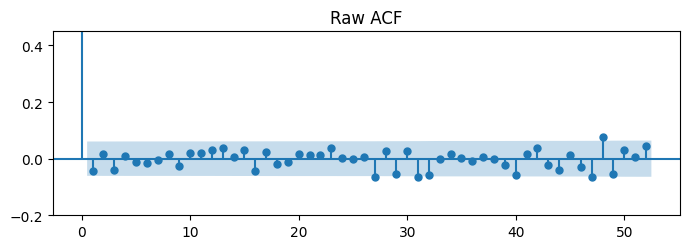

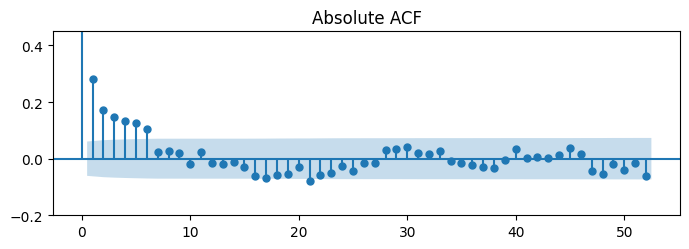

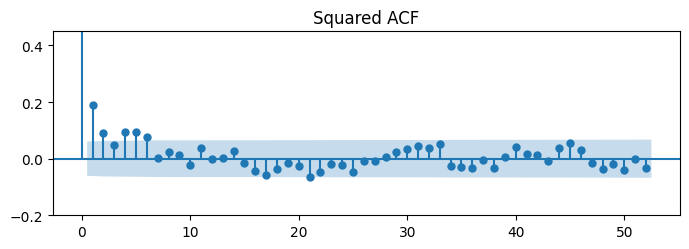

In [62]:
for series, title in [(log_returns_synth, "Raw ACF"),
                      (log_returns_synth.abs(), "Absolute ACF"),
                      (log_returns_synth ** 2, "Squared ACF")]:
    fig, ax = plt.subplots(figsize=(7, 2.6))
    plot_acf(series, lags=52, ax=ax, title=title)
    ax.set_ylim(-0.2, 0.45)
    plt.tight_layout()
    plt.show()

In [63]:
compare_rows = ["SPY 2000-2019", "Synthetic 1042n", "Synthetic 50000n"]
compare_columns = ["Weekly Std", "Excess Kurtosis", "ACF(r) lag1", "ACF(|r|) lag1", "ACF(|r|) lag5", "ACF(|r|) lag10"]

spy_log_returns = spy_weekly_data["Log_Return"].dropna()

state_chain_50000 = simulate_chain(P_matrice, 50000, 0, rng)
log_return_array_50000 = markov_switching_return(logReturn_mean, low_vol_average_std, high_vol_average_std, state_chain_50000, rng)

synth_return_50000 = pd.DataFrame(log_return_array_50000, columns=["Log_Return"])
log_returns_synth_50000 = synth_return_50000["Log_Return"].dropna()


theoretical_std = np.sqrt(s[0] * (low_vol_average_std**2) + s[1] * (high_vol_average_std**2))
print(f"\n--- STANDARD DEVIATION CHECK ---")
print(f"Theoretical Std (Mixture Formula): {theoretical_std:.6f}")
print(f"SPY Empirical Std                : {spy_log_returns.std():.6f}")
print(f"Synthetic 1042 Std               : {log_returns_synth.std():.6f}")
print(f"Synthetic 50000 Std              : {log_returns_synth_50000.std():.6f}\n")

# Tablo Verileri
compare_table_datas = [
    [
        spy_log_returns.std(), 
        spy_log_returns.kurtosis(), 
        acf(spy_log_returns, nlags=1)[1], 
        acf(spy_log_returns.abs(), nlags=1)[1], 
        acf(spy_log_returns.abs(), nlags=5)[5], 
        acf(spy_log_returns.abs(), nlags=10)[10]
    ],
    [
        log_returns_synth.std(), 
        log_returns_synth.kurtosis(), 
        acf(log_returns_synth, nlags=1)[1], 
        acf(log_returns_synth.abs(), nlags=1)[1], 
        acf(log_returns_synth.abs(), nlags=5)[5], 
        acf(log_returns_synth.abs(), nlags=10)[10]
    ],
    [
        log_returns_synth_50000.std(), 
        log_returns_synth_50000.kurtosis(), 
        acf(log_returns_synth_50000, nlags=1)[1], 
        acf(log_returns_synth_50000.abs(), nlags=1)[1], 
        acf(log_returns_synth_50000.abs(), nlags=5)[5], 
        acf(log_returns_synth_50000.abs(), nlags=10)[10]
    ]
]

compare_df = pd.DataFrame(compare_table_datas, index=compare_rows, columns=compare_columns)
print(compare_df)



--- STANDARD DEVIATION CHECK ---
Theoretical Std (Mixture Formula): 0.026000
SPY Empirical Std                : 0.024140
Synthetic 1042 Std               : 0.026519
Synthetic 50000 Std              : 0.026254

                  Weekly Std  Excess Kurtosis  ACF(r) lag1  ACF(|r|) lag1  \
SPY 2000-2019         0.0241           9.4766      -0.0692         0.2997   
Synthetic 1042n       0.0265           5.0342      -0.0431         0.2826   
Synthetic 50000n      0.0263           6.8440      -0.0034         0.2920   

                  ACF(|r|) lag5  ACF(|r|) lag10  
SPY 2000-2019            0.2013          0.0993  
Synthetic 1042n          0.1275         -0.0185  
Synthetic 50000n         0.0989          0.0256  


In [64]:


scenarios = [
    {"name": "1. Base Case",        "P00": 0.95, "P11": 0.80, "sig0": 0.013, "sig1": 0.052},
    {"name": "2. High Persistence", "P00": 0.99, "P11": 0.95, "sig0": 0.013, "sig1": 0.052},
    {"name": "3. Low Persistence",  "P00": 0.50, "P11": 0.50, "sig0": 0.013, "sig1": 0.052},
    {"name": "4. Extreme High Vol", "P00": 0.95, "P11": 0.80, "sig0": 0.013, "sig1": 0.120},
    {"name": "5. Similar Vols",     "P00": 0.95, "P11": 0.80, "sig0": 0.013, "sig1": 0.018}
]

sensitivity_results = []
sim_size = 50000

for scen in scenarios:
    P_scen = np.array([
        [scen["P00"], 1 - scen["P00"]],
        [1 - scen["P11"], scen["P11"]]
    ])
    
    chain_rng = np.random.default_rng(seed=123)
    noise_rng = np.random.default_rng(seed=456)
    
    chain_scen = simulate_chain(P_scen, sim_size, 0, chain_rng)
    ret_scen = markov_switching_return(logReturn_mean, scen["sig0"], scen["sig1"], chain_scen, noise_rng)
    
    ret_series = pd.Series(ret_scen)
    std_val = ret_series.std()
    kurt_val = ret_series.kurtosis()
    acf_abs_1 = acf(ret_series.abs(), nlags=1)[1]
    acf_abs_10 = acf(ret_series.abs(), nlags=10)[10]
    
    sensitivity_results.append([
        scen["name"], scen["P00"], scen["P11"], scen["sig0"], scen["sig1"], 
        std_val, kurt_val, acf_abs_1, acf_abs_10
    ])

sens_columns = ["Scenario", "P_00", "P_11", "Vol_Low", "Vol_High", "Std", "Excess Kurtosis", "ACF(|r|) lag1", "ACF(|r|) lag10"]
sens_df = pd.DataFrame(sensitivity_results, columns=sens_columns)
sens_df.set_index("Scenario", inplace=True)

pd.options.display.float_format = '{:.4f}'.format
print(sens_df)

                      P_00   P_11  Vol_Low  Vol_High    Std  Excess Kurtosis  \
Scenario                                                                       
1. Base Case        0.9500 0.8000   0.0130    0.0520 0.0261           6.8310   
2. High Persistence 0.9900 0.9500   0.0130    0.0520 0.0247           7.3801   
3. Low Persistence  0.5000 0.5000   0.0130    0.0520 0.0377           2.3167   
4. Extreme High Vol 0.9500 0.8000   0.0130    0.1200 0.0551          10.7556   
5. Similar Vols     0.9500 0.8000   0.0130    0.0180 0.0141           0.3096   

                     ACF(|r|) lag1  ACF(|r|) lag10  
Scenario                                            
1. Base Case                0.2969          0.0279  
2. High Persistence         0.3688          0.2103  
3. Low Persistence          0.0008         -0.0022  
4. Extreme High Vol         0.3929          0.0383  
5. Similar Vols             0.0295         -0.0003  
